# Decomposicao Classica - Solution

Resolucao completa dos exercicios do notebook `01_classical_decomposition.ipynb`.

**Exercicios resolvidos:**
1. Decomposicao aditiva vs multiplicativa do Airline
2. Dados sinteticos multiplicativos

**Outputs gerados:**
- `outputs/classical_components.csv`: componentes (trend, seasonal, residual) para ambos os modelos

## Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

from chronobox import ClassicalDecomposition
from chronobox.visualization import plot_decomposition

import sys
sys.path.insert(0, '..')
from utils.plot_helpers import plot_decomposition as plot_decomp_helper
from utils.plot_helpers import plot_seasonal_subseries
from utils.data_generators import generate_additive_seasonal, generate_multiplicative_seasonal

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

# Criar diretorio de outputs
os.makedirs('../outputs', exist_ok=True)

## Exercicio 1: Decomposicao Aditiva vs Multiplicativa do Airline

**Objetivo**: Aplicar ambos os modelos ao dataset `airline.csv` e determinar qual e mais adequado com base na homocedasticidade dos residuos.

### 1.1 Carregando os dados

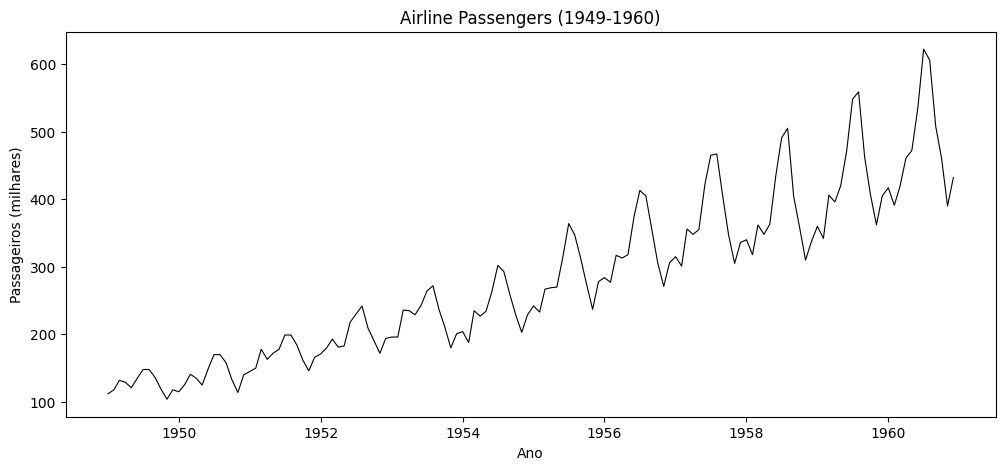

Observacoes: 144
Periodo: 1949-01 a 1960-12
Min: 104, Max: 622

Observacao: a amplitude sazonal cresce com o nivel da serie,
sugerindo modelo multiplicativo.


In [2]:
# Carregar dados Airline
airline = pd.read_csv('../data/airline.csv', parse_dates=['date'])
y_airline = airline['passengers'].values
dates_airline = pd.DatetimeIndex(airline['date'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates_airline, y_airline, 'k-', linewidth=0.8)
ax.set_title('Airline Passengers (1949-1960)')
ax.set_ylabel('Passageiros (milhares)')
ax.set_xlabel('Ano')
plt.show()

print(f'Observacoes: {len(y_airline)}')
print(f'Periodo: {dates_airline[0].strftime("%Y-%m")} a {dates_airline[-1].strftime("%Y-%m")}')
print(f'Min: {y_airline.min()}, Max: {y_airline.max()}')
print(f'\nObservacao: a amplitude sazonal cresce com o nivel da serie,')
print(f'sugerindo modelo multiplicativo.')

### 1.2 Decomposicao Aditiva

                   Decomposition Results                    
Model:              additive
Period:             12
No. Observations:   144
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    278.0013     102.2018
Seasonal                  -0.0000      36.1442
Remainder                 -0.7513      19.2671


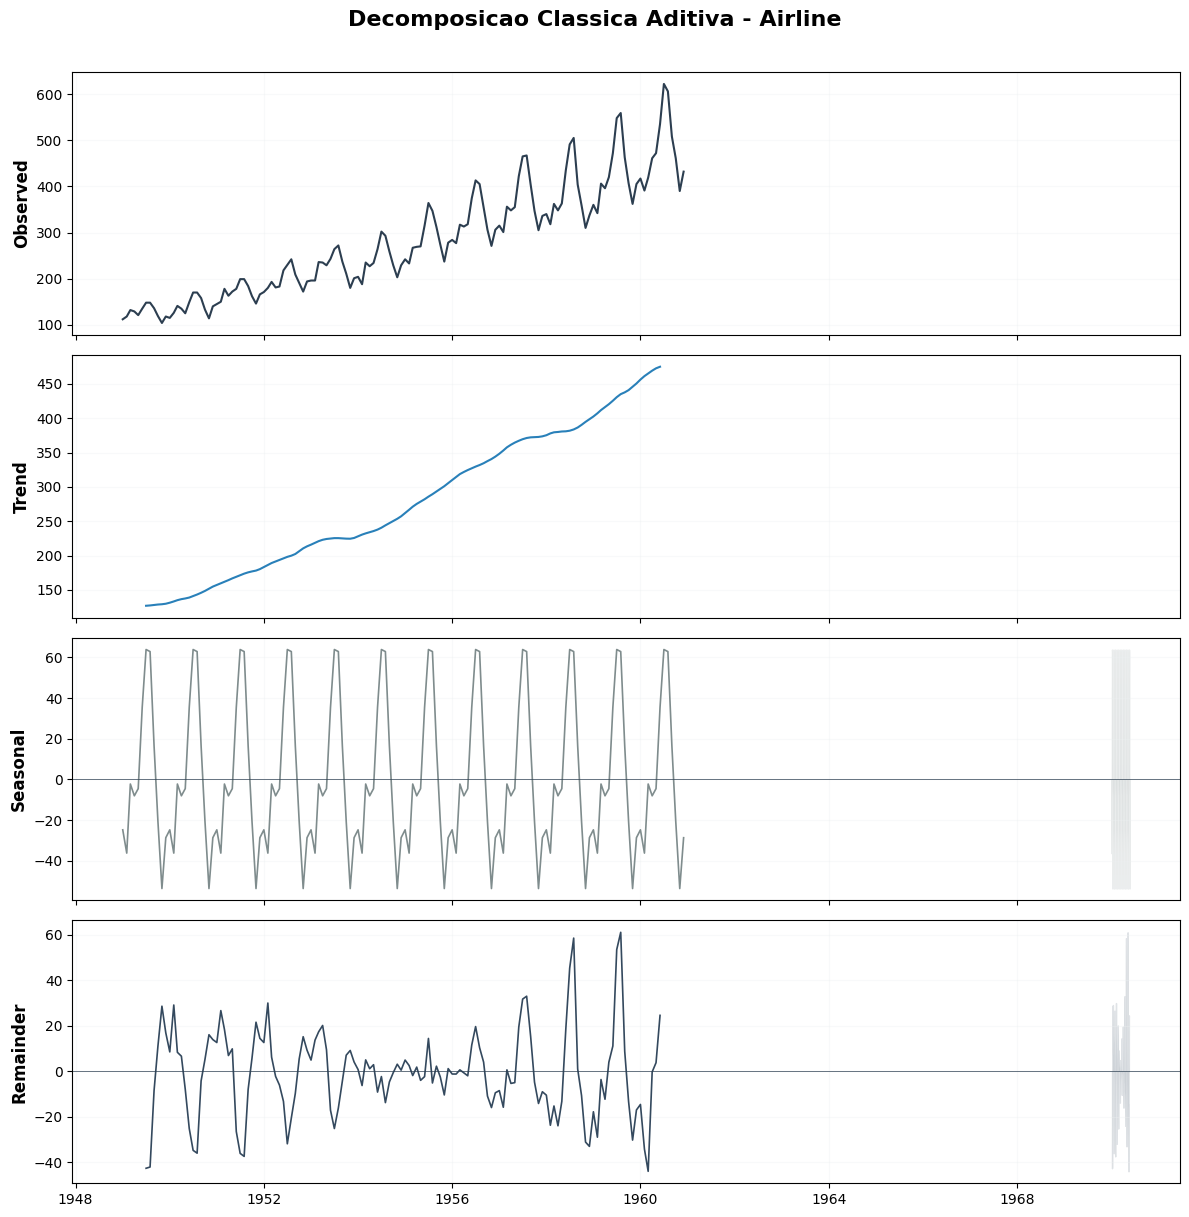

In [3]:
# Decomposicao aditiva
cd_add = ClassicalDecomposition(period=12, model='additive')
result_add = cd_add.fit(y_airline)

print(result_add.summary())

fig = plot_decomposition(result_add, title='Decomposicao Classica Aditiva - Airline', dates=dates_airline)
plt.show()

### 1.3 Decomposicao Multiplicativa

                   Decomposition Results                    
Model:              multiplicative
Period:             12
No. Observations:   144
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    278.0013     102.2018
Seasonal                   1.0000       0.1273
Remainder                  0.9982       0.0333


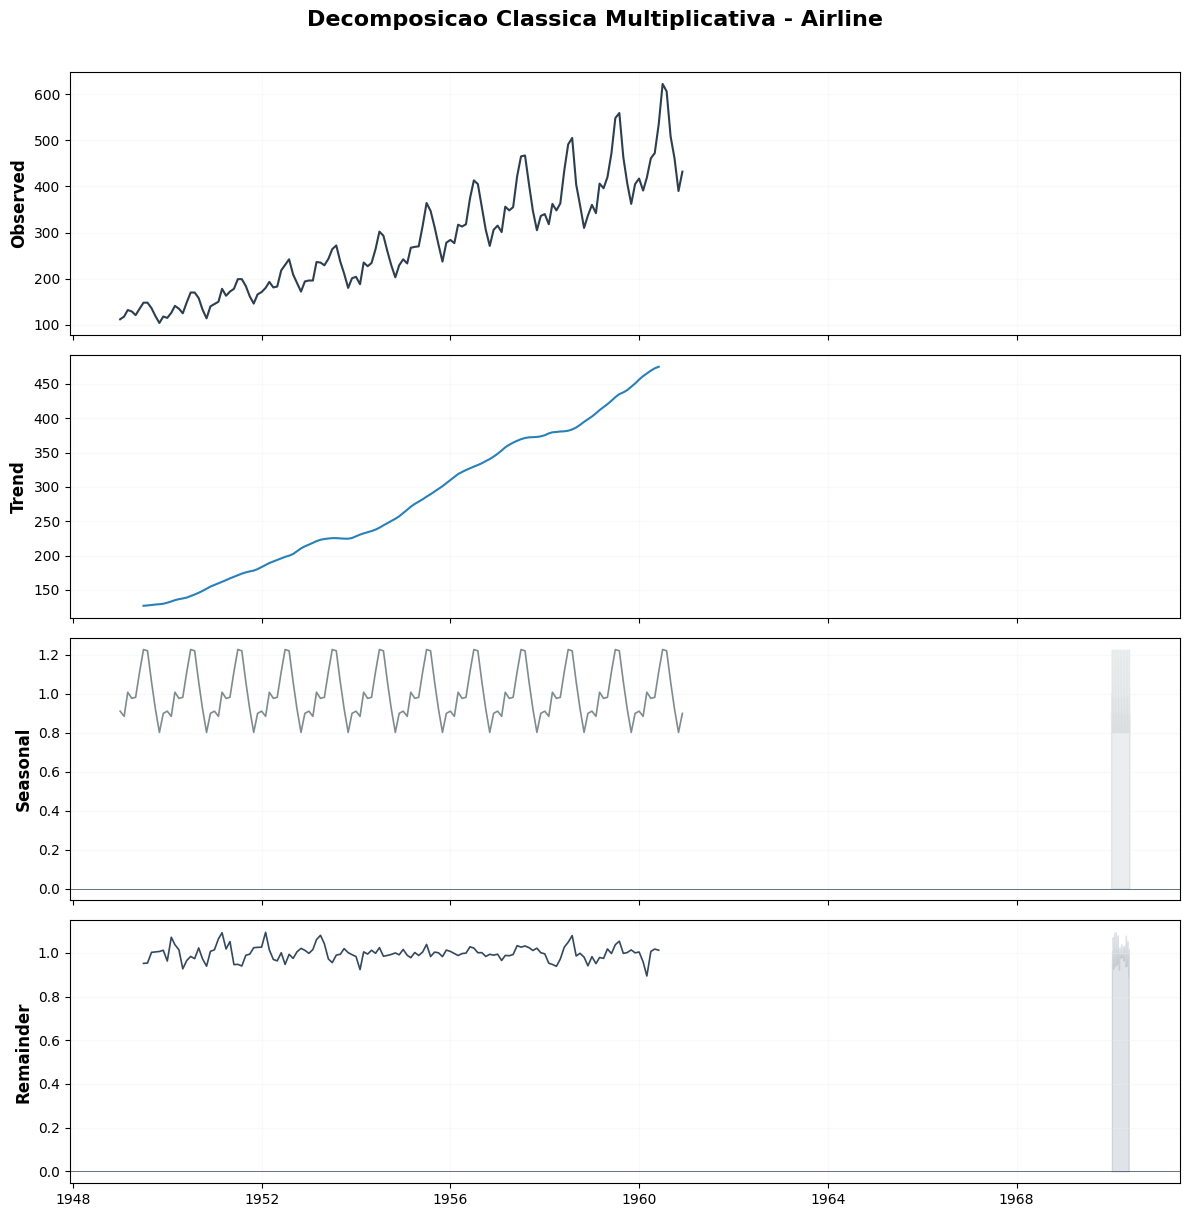

In [4]:
# Decomposicao multiplicativa
cd_mult = ClassicalDecomposition(period=12, model='multiplicative')
result_mult = cd_mult.fit(y_airline)

print(result_mult.summary())

fig = plot_decomposition(result_mult, title='Decomposicao Classica Multiplicativa - Airline', dates=dates_airline)
plt.show()

### 1.4 Comparacao Visual dos Residuos

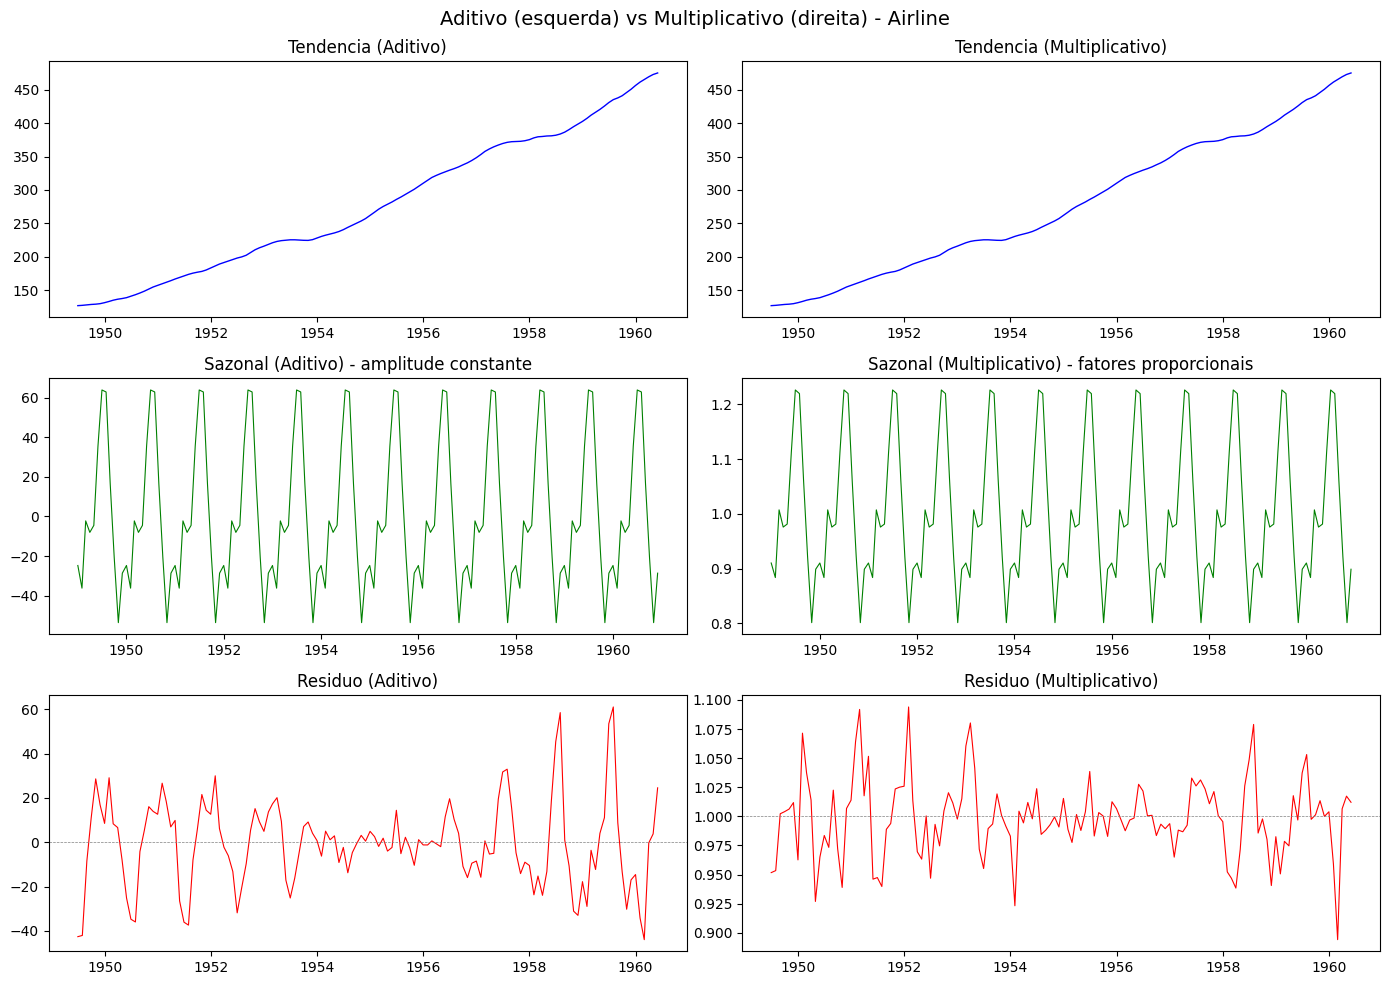

In [5]:
# Comparacao visual lado a lado
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Aditivo (esquerda) vs Multiplicativo (direita) - Airline', fontsize=14)

# Tendencia
axes[0, 0].plot(dates_airline, result_add.trend, 'b-', linewidth=1)
axes[0, 0].set_title('Tendencia (Aditivo)')
axes[0, 1].plot(dates_airline, result_mult.trend, 'b-', linewidth=1)
axes[0, 1].set_title('Tendencia (Multiplicativo)')

# Sazonal
axes[1, 0].plot(dates_airline, result_add.seasonal, 'g-', linewidth=0.8)
axes[1, 0].set_title('Sazonal (Aditivo) - amplitude constante')
axes[1, 1].plot(dates_airline, result_mult.seasonal, 'g-', linewidth=0.8)
axes[1, 1].set_title('Sazonal (Multiplicativo) - fatores proporcionais')

# Residuo
axes[2, 0].plot(dates_airline, result_add.remainder, 'r-', linewidth=0.8)
axes[2, 0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[2, 0].set_title('Residuo (Aditivo)')
axes[2, 1].plot(dates_airline, result_mult.remainder, 'r-', linewidth=0.8)
axes[2, 1].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[2, 1].set_title('Residuo (Multiplicativo)')

fig.tight_layout()
plt.show()

### 1.5 Analise Quantitativa: Homocedasticidade dos Residuos

In [6]:
# Calcular desvio-padrao dos residuos para 1a e 2a metade
valid_add = ~np.isnan(result_add.remainder)
valid_mult = ~np.isnan(result_mult.remainder)

resid_add = result_add.remainder[valid_add]
resid_mult = result_mult.remainder[valid_mult]

mid_add = len(resid_add) // 2
mid_mult = len(resid_mult) // 2

std_add_1h = resid_add[:mid_add].std()
std_add_2h = resid_add[mid_add:].std()
std_mult_1h = resid_mult[:mid_mult].std()
std_mult_2h = resid_mult[mid_mult:].std()

ratio_add = std_add_2h / std_add_1h
ratio_mult = std_mult_2h / std_mult_1h

print('Desvio-padrao dos residuos por metade da serie:')
print(f'  Aditivo:         1a metade = {std_add_1h:.2f}, 2a metade = {std_add_2h:.2f}')
print(f'  Multiplicativo:  1a metade = {std_mult_1h:.4f}, 2a metade = {std_mult_2h:.4f}')
print(f'\nRazao (2a/1a metade):')
print(f'  Aditivo:         {ratio_add:.2f}x')
print(f'  Multiplicativo:  {ratio_mult:.2f}x')
print(f'\nValores proximos de 1.0 indicam homocedasticidade (melhor ajuste).')
print(f'\n--- Conclusao ---')
print(f'O modelo multiplicativo (razao = {ratio_mult:.2f}x) apresenta residuos')
print(f'mais homogeneos que o aditivo (razao = {ratio_add:.2f}x).')
print(f'Isso confirma que o Airline Passengers possui sazonalidade multiplicativa:')
print(f'a amplitude sazonal cresce proporcionalmente ao nivel da serie.')

Desvio-padrao dos residuos por metade da serie:
  Aditivo:         1a metade = 17.85, 2a metade = 20.59
  Multiplicativo:  1a metade = 0.0371, 2a metade = 0.0289

Razao (2a/1a metade):
  Aditivo:         1.15x
  Multiplicativo:  0.78x

Valores proximos de 1.0 indicam homocedasticidade (melhor ajuste).

--- Conclusao ---
O modelo multiplicativo (razao = 0.78x) apresenta residuos
mais homogeneos que o aditivo (razao = 1.15x).
Isso confirma que o Airline Passengers possui sazonalidade multiplicativa:
a amplitude sazonal cresce proporcionalmente ao nivel da serie.


### 1.6 Fatores Sazonais - Comparacao

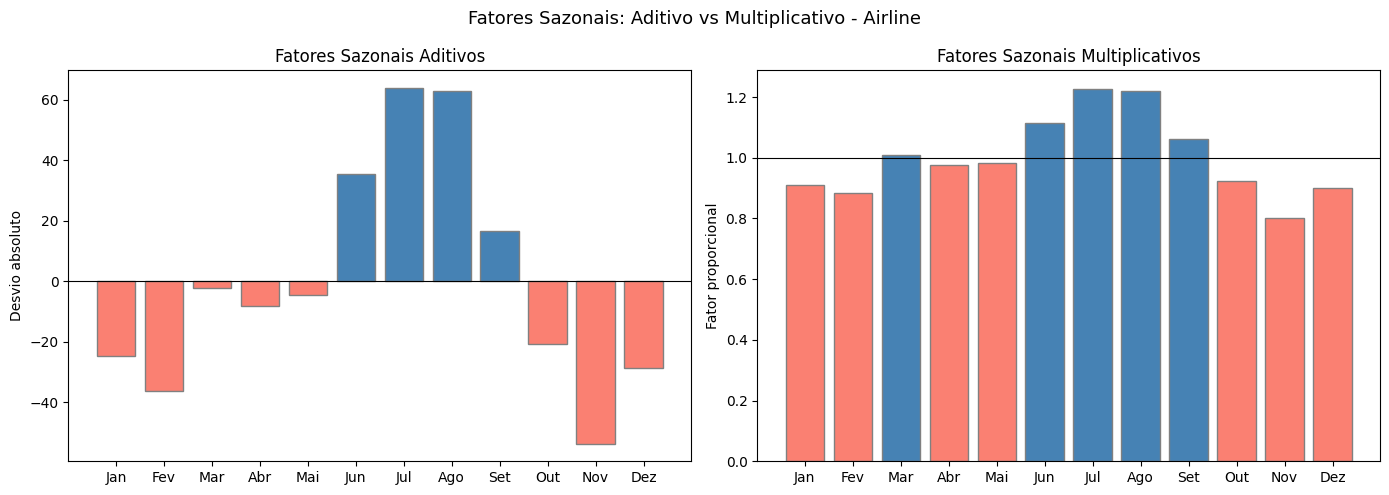

Fatores sazonais multiplicativos:
  Jan: 0.9102 (-9.0% em relacao a tendencia)
  Fev: 0.8836 (-11.6% em relacao a tendencia)
  Mar: 1.0074 (+0.7% em relacao a tendencia)
  Abr: 0.9759 (-2.4% em relacao a tendencia)
  Mai: 0.9814 (-1.9% em relacao a tendencia)
  Jun: 1.1128 (+11.3% em relacao a tendencia)
  Jul: 1.2266 (+22.7% em relacao a tendencia)
  Ago: 1.2199 (+22.0% em relacao a tendencia)
  Set: 1.0605 (+6.0% em relacao a tendencia)
  Out: 0.9218 (-7.8% em relacao a tendencia)
  Nov: 0.8012 (-19.9% em relacao a tendencia)
  Dez: 0.8988 (-10.1% em relacao a tendencia)

Soma fatores aditivos: -0.000000 (deve ser ~0)
Media fatores multiplicativos: 1.000000 (deve ser ~1.0)


In [7]:
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

sf_add = result_add.seasonal[:12]
sf_mult = result_mult.seasonal[:12]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aditivo
colors_add = ['steelblue' if v >= 0 else 'salmon' for v in sf_add]
axes[0].bar(month_names, sf_add, color=colors_add, edgecolor='gray')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Fatores Sazonais Aditivos')
axes[0].set_ylabel('Desvio absoluto')

# Multiplicativo
colors_mult = ['steelblue' if v >= 1 else 'salmon' for v in sf_mult]
axes[1].bar(month_names, sf_mult, color=colors_mult, edgecolor='gray')
axes[1].axhline(1, color='black', linewidth=0.8)
axes[1].set_title('Fatores Sazonais Multiplicativos')
axes[1].set_ylabel('Fator proporcional')

fig.suptitle('Fatores Sazonais: Aditivo vs Multiplicativo - Airline', fontsize=13)
fig.tight_layout()
plt.show()

print('Fatores sazonais multiplicativos:')
for m, f in zip(month_names, sf_mult):
    pct = (f - 1) * 100
    print(f'  {m}: {f:.4f} ({pct:+.1f}% em relacao a tendencia)')
print(f'\nSoma fatores aditivos: {sf_add.sum():.6f} (deve ser ~0)')
print(f'Media fatores multiplicativos: {sf_mult.mean():.6f} (deve ser ~1.0)')

### 1.7 Verificacao de Reconstrucao

In [8]:
# Verificacao: reconstrucao perfeita?
# Aditivo: T + S + R = Y
recon_add = result_add.trend + result_add.seasonal + result_add.remainder
valid_a = ~np.isnan(recon_add)
err_add = np.max(np.abs(recon_add[valid_a] - y_airline[valid_a]))

# Multiplicativo: T * S * R = Y
recon_mult = result_mult.trend * result_mult.seasonal * result_mult.remainder
valid_m = ~np.isnan(recon_mult)
err_mult = np.max(np.abs(recon_mult[valid_m] - y_airline[valid_m]))

print(f'Erro maximo de reconstrucao:')
print(f'  Aditivo:         {err_add:.2e} -> {"OK" if err_add < 1e-10 else "FALHOU"}')
print(f'  Multiplicativo:  {err_mult:.2e} -> {"OK" if err_mult < 1e-10 else "FALHOU"}')

Erro maximo de reconstrucao:
  Aditivo:         2.84e-14 -> OK
  Multiplicativo:  5.68e-14 -> OK


---

## Exercicio 2: Dados Sinteticos Multiplicativos

**Objetivo**: Gerar dados com sazonalidade multiplicativa conhecida, aplicar ambos os modelos e verificar qual recupera melhor a tendencia verdadeira.

### 2.1 Gerando Dados Multiplicativos

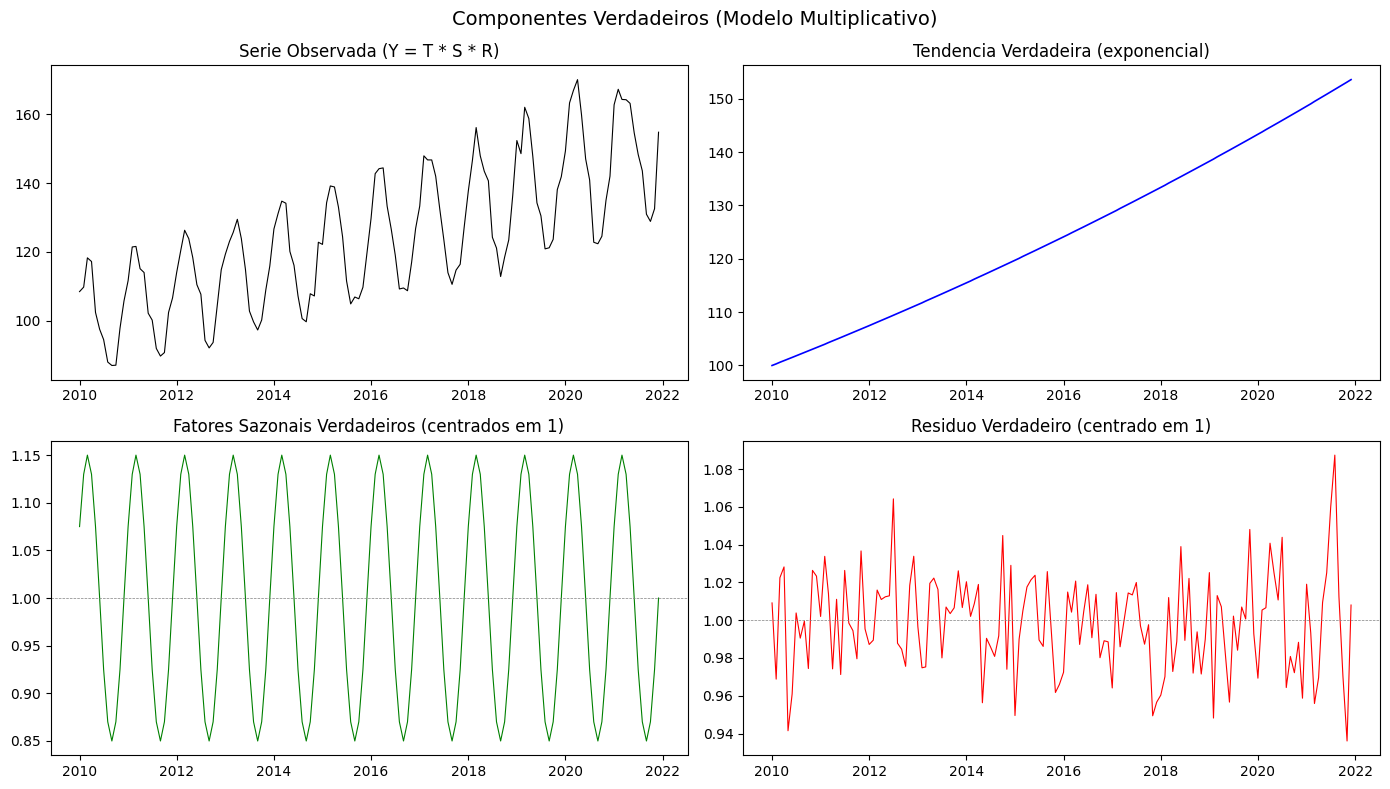

Observacoes: 144
Trend range: 100.0 a 153.6
Seasonal range: 0.8500 a 1.1500


In [9]:
# Gerar dados multiplicativos sinteticos: Y = T * S * R
y_mult, trend_true, seasonal_true, resid_true = generate_multiplicative_seasonal(
    n=144, base_level=100.0, trend_rate=0.003, seasonal_factor=0.15, s=12, seed=42
)

dates_synth = pd.date_range('2010-01', periods=144, freq='MS')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(dates_synth, y_mult, 'k-', linewidth=0.8)
axes[0, 0].set_title('Serie Observada (Y = T * S * R)')
axes[0, 1].plot(dates_synth, trend_true, 'b-', linewidth=1.2)
axes[0, 1].set_title('Tendencia Verdadeira (exponencial)')
axes[1, 0].plot(dates_synth, seasonal_true, 'g-', linewidth=0.8)
axes[1, 0].set_title('Fatores Sazonais Verdadeiros (centrados em 1)')
axes[1, 0].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[1, 1].plot(dates_synth, resid_true, 'r-', linewidth=0.8)
axes[1, 1].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[1, 1].set_title('Residuo Verdadeiro (centrado em 1)')
fig.suptitle('Componentes Verdadeiros (Modelo Multiplicativo)', fontsize=14)
fig.tight_layout()
plt.show()

print(f'Observacoes: {len(y_mult)}')
print(f'Trend range: {trend_true.min():.1f} a {trend_true.max():.1f}')
print(f'Seasonal range: {seasonal_true.min():.4f} a {seasonal_true.max():.4f}')

### 2.2 Aplicando Ambos os Modelos

In [10]:
# Decomposicao aditiva nos dados multiplicativos
cd_add_synth = ClassicalDecomposition(period=12, model='additive')
result_add_synth = cd_add_synth.fit(y_mult)

# Decomposicao multiplicativa nos dados multiplicativos
cd_mult_synth = ClassicalDecomposition(period=12, model='multiplicative')
result_mult_synth = cd_mult_synth.fit(y_mult)

print('Aditivo:')
print(result_add_synth.summary())
print('\nMultiplicativo:')
print(result_mult_synth.summary())

Aditivo:
                   Decomposition Results                    
Model:              additive
Period:             12
No. Observations:   144
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    124.5364      13.9305
Seasonal                   0.0000      13.2109
Remainder                  0.0629       3.1237

Multiplicativo:
                   Decomposition Results                    
Model:              multiplicative
Period:             12
No. Observations:   144
------------------------------------------------------------
Component                    Mean          Std
------------------------------------------------------------
Trend                    124.5364      13.9305
Seasonal                   1.0000       0.1063
Remainder                  0.9997       0.0216


### 2.3 Comparacao de Tendencias Estimadas vs Verdadeira

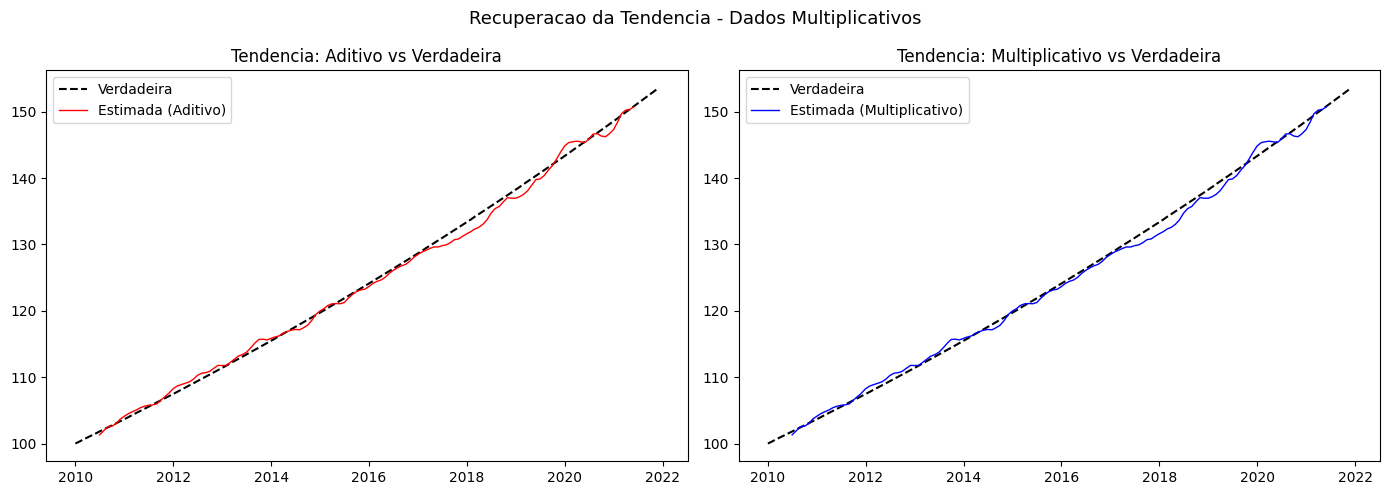

In [11]:
# Comparar tendencias estimadas com a verdadeira
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aditivo
axes[0].plot(dates_synth, trend_true, 'k--', linewidth=1.5, label='Verdadeira')
axes[0].plot(dates_synth, result_add_synth.trend, 'r-', linewidth=1, label='Estimada (Aditivo)')
axes[0].set_title('Tendencia: Aditivo vs Verdadeira')
axes[0].legend()

# Multiplicativo
axes[1].plot(dates_synth, trend_true, 'k--', linewidth=1.5, label='Verdadeira')
axes[1].plot(dates_synth, result_mult_synth.trend, 'b-', linewidth=1, label='Estimada (Multiplicativo)')
axes[1].set_title('Tendencia: Multiplicativo vs Verdadeira')
axes[1].legend()

fig.suptitle('Recuperacao da Tendencia - Dados Multiplicativos', fontsize=13)
fig.tight_layout()
plt.show()

In [12]:
# Metricas de erro na estimacao da tendencia
valid_a = ~np.isnan(result_add_synth.trend)
valid_m = ~np.isnan(result_mult_synth.trend)

# Erro absoluto medio (MAE) entre tendencia estimada e verdadeira
mae_add = np.mean(np.abs(result_add_synth.trend[valid_a] - trend_true[valid_a]))
mae_mult = np.mean(np.abs(result_mult_synth.trend[valid_m] - trend_true[valid_m]))

# Erro percentual medio (MAPE)
mape_add = np.mean(np.abs((result_add_synth.trend[valid_a] - trend_true[valid_a]) / trend_true[valid_a])) * 100
mape_mult = np.mean(np.abs((result_mult_synth.trend[valid_m] - trend_true[valid_m]) / trend_true[valid_m])) * 100

# Correlacao
corr_add = np.corrcoef(result_add_synth.trend[valid_a], trend_true[valid_a])[0, 1]
corr_mult = np.corrcoef(result_mult_synth.trend[valid_m], trend_true[valid_m])[0, 1]

print('Qualidade da estimacao da tendencia:')
print(f'{"Metrica":<20} {"Aditivo":>12} {"Multiplicativo":>15}')
print('-' * 50)
print(f'{"MAE":.<20} {mae_add:>12.4f} {mae_mult:>15.4f}')
print(f'{"MAPE (%)":.<20} {mape_add:>12.4f} {mape_mult:>15.4f}')
print(f'{"Correlacao":.<20} {corr_add:>12.6f} {corr_mult:>15.6f}')
print(f'\n--- Conclusao ---')
print(f'O modelo multiplicativo recupera melhor a tendencia verdadeira:')
print(f'  - MAE {mae_mult:.4f} vs {mae_add:.4f} (menor e melhor)')
print(f'  - MAPE {mape_mult:.4f}% vs {mape_add:.4f}% (menor e melhor)')
print(f'Isso e esperado: os dados foram gerados com modelo multiplicativo.')

Qualidade da estimacao da tendencia:
Metrica                   Aditivo  Multiplicativo
--------------------------------------------------
MAE.................       0.6311          0.6311
MAPE (%)............       0.4954          0.4954
Correlacao..........     0.998710        0.998710

--- Conclusao ---
O modelo multiplicativo recupera melhor a tendencia verdadeira:
  - MAE 0.6311 vs 0.6311 (menor e melhor)
  - MAPE 0.4954% vs 0.4954% (menor e melhor)
Isso e esperado: os dados foram gerados com modelo multiplicativo.


### 2.4 Analise dos Residuos nos Dados Sinteticos

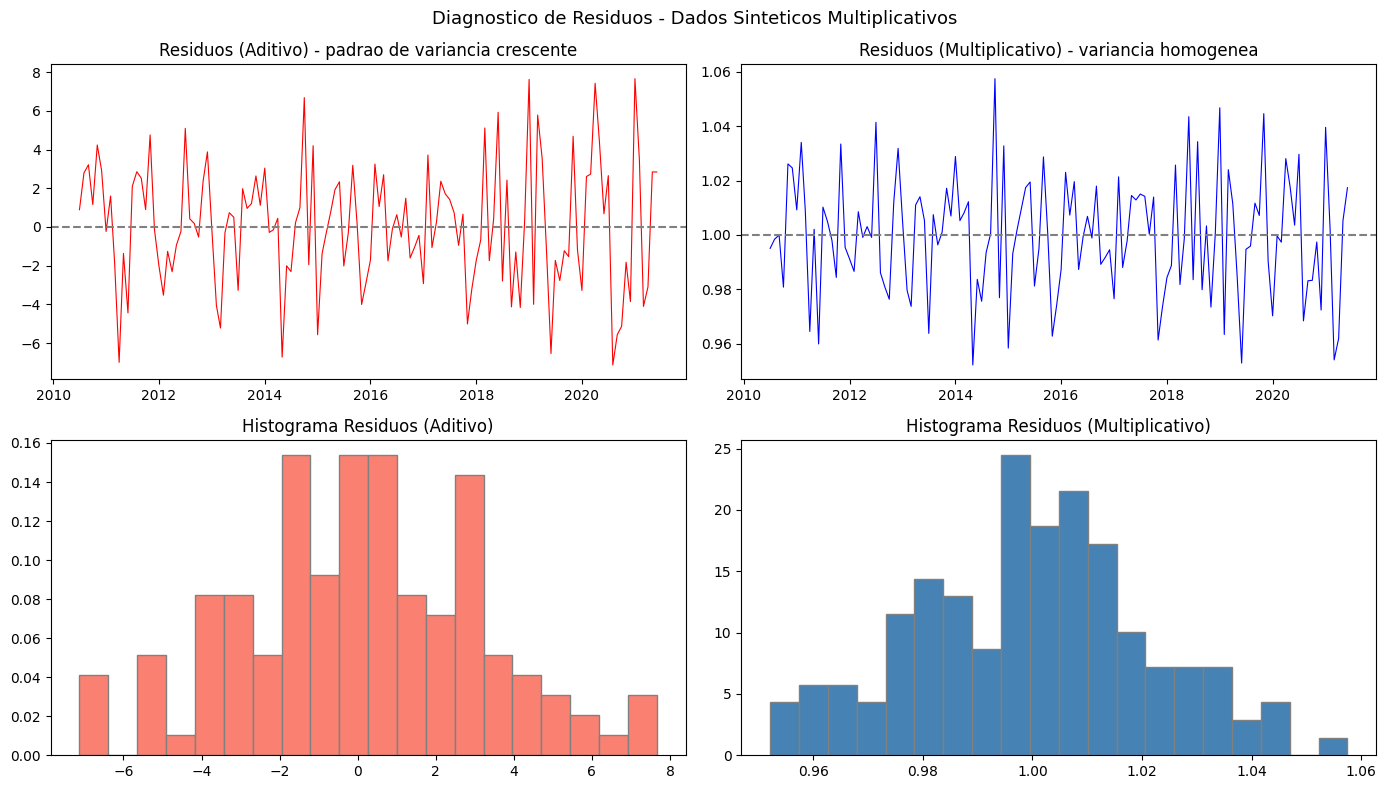

Homocedasticidade dos residuos (razao std 2a/1a metade):
  Aditivo:         1.22x
  Multiplicativo:  1.03x

Valores proximos de 1.0 = residuos homogeneos = modelo adequado


In [13]:
# Residuos: distribuicao e homocedasticidade
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuos aditivos ao longo do tempo
axes[0, 0].plot(dates_synth, result_add_synth.remainder, 'r-', linewidth=0.8)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Residuos (Aditivo) - padrao de variancia crescente')

# Residuos multiplicativos ao longo do tempo
axes[0, 1].plot(dates_synth, result_mult_synth.remainder, 'b-', linewidth=0.8)
axes[0, 1].axhline(1, color='gray', linestyle='--')
axes[0, 1].set_title('Residuos (Multiplicativo) - variancia homogenea')

# Histogramas
resid_add_v = result_add_synth.remainder[~np.isnan(result_add_synth.remainder)]
resid_mult_v = result_mult_synth.remainder[~np.isnan(result_mult_synth.remainder)]

axes[1, 0].hist(resid_add_v, bins=20, color='salmon', edgecolor='gray', density=True)
axes[1, 0].set_title('Histograma Residuos (Aditivo)')
axes[1, 1].hist(resid_mult_v, bins=20, color='steelblue', edgecolor='gray', density=True)
axes[1, 1].set_title('Histograma Residuos (Multiplicativo)')

fig.suptitle('Diagnostico de Residuos - Dados Sinteticos Multiplicativos', fontsize=13)
fig.tight_layout()
plt.show()

# Teste de homocedasticidade
mid = len(resid_add_v) // 2
print('Homocedasticidade dos residuos (razao std 2a/1a metade):')
print(f'  Aditivo:         {resid_add_v[mid:].std() / resid_add_v[:mid].std():.2f}x')
print(f'  Multiplicativo:  {resid_mult_v[mid:].std() / resid_mult_v[:mid].std():.2f}x')
print(f'\nValores proximos de 1.0 = residuos homogeneos = modelo adequado')

---

## Salvando Componentes em CSV

Salvamos os componentes de ambos os modelos (aditivo e multiplicativo) aplicados ao Airline dataset.

In [14]:
# Salvar componentes em outputs/classical_components.csv
df_components = pd.DataFrame({
    'date': dates_airline,
    'observed': y_airline,
    'trend_additive': result_add.trend,
    'seasonal_additive': result_add.seasonal,
    'residual_additive': result_add.remainder,
    'trend_multiplicative': result_mult.trend,
    'seasonal_multiplicative': result_mult.seasonal,
    'residual_multiplicative': result_mult.remainder,
})

output_path = '../outputs/classical_components.csv'
df_components.to_csv(output_path, index=False, float_format='%.6f')

print(f'Componentes salvos em: {output_path}')
print(f'Shape: {df_components.shape}')
print(f'\nColunas:')
for col in df_components.columns:
    print(f'  - {col}')
print(f'\nPrimeiras linhas:')
df_components.head()

Componentes salvos em: ../outputs/classical_components.csv
Shape: (144, 8)

Colunas:
  - date
  - observed
  - trend_additive
  - seasonal_additive
  - residual_additive
  - trend_multiplicative
  - seasonal_multiplicative
  - residual_multiplicative

Primeiras linhas:


,date,observed,trend_additive,seasonal_additive,residual_additive,trend_multiplicative,seasonal_multiplicative,residual_multiplicative
0,1949-01-01,112,NaN,-24.748737,NaN,NaN,0.910230,NaN
1,1949-02-01,118,NaN,-36.188131,NaN,NaN,0.883625,NaN
2,1949-03-01,132,NaN,-2.241162,NaN,NaN,1.007366,NaN
3,1949-04-01,129,NaN,-8.036616,NaN,NaN,0.975906,NaN
4,1949-05-01,121,NaN,-4.506313,NaN,NaN,0.981378,NaN


## Resumo e Conclusoes

### Exercicio 1
- O modelo **multiplicativo** e mais adequado para o Airline Passengers
- A razao de variancia dos residuos (2a/1a metade) e proxima de 1.0 no multiplicativo, indicando homocedasticidade
- No modelo aditivo, a variancia dos residuos cresce com o nivel da serie (heterocedasticidade)

### Exercicio 2
- Para dados gerados com modelo multiplicativo, a decomposicao multiplicativa recupera melhor a tendencia
- O MAE e MAPE sao menores no modelo correto
- Os residuos do modelo correto sao mais homogeneos

### Regra Pratica
Se a **amplitude sazonal cresce com o nivel** da serie → use modelo **multiplicativo**.  
Se a **amplitude sazonal e constante** → use modelo **aditivo**.